# Prétraitement de l'audio

L'exécution de ce notebook nécessite que le dataset `GuitarSet` soit ingéré.

## Imports

In [ ]:
import sys
from pathlib import Path

AUDIO_MIDI_DIRECTORY = Path.cwd().parent
sys.path.append(AUDIO_MIDI_DIRECTORY.as_posix())

In [ ]:
# Chemins
OUTPUT_DIRECTORY = AUDIO_MIDI_DIRECTORY / "output"
FIGURES_DIRECTORY = OUTPUT_DIRECTORY / "figures"

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

In [3]:
# Imports EDA
import numpy as np

In [4]:
# Imports graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Accessibilité : Daltonisme, Dyslexie, Confort Visuel
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

In [5]:
# Imports storages
from config import minio_config
from src.storages import MinIOStorage

minio = MinIOStorage()

c:\Users\Administrateur\Documents\M2i_CDSD_Projet\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Chargement d'un audio

In [6]:
title = "00_BN1-129-Eb_comp"
audio_data, sample_rate = minio.get_audio(
    bucket_name=minio_config.bucket_raw,
    file_name=f"GuitarSet/{title}/audio_mono-pickup_mix.wav",
)

print(f"Nombre de canaux : {len(audio_data.shape)}")

Nombre de canaux : 1


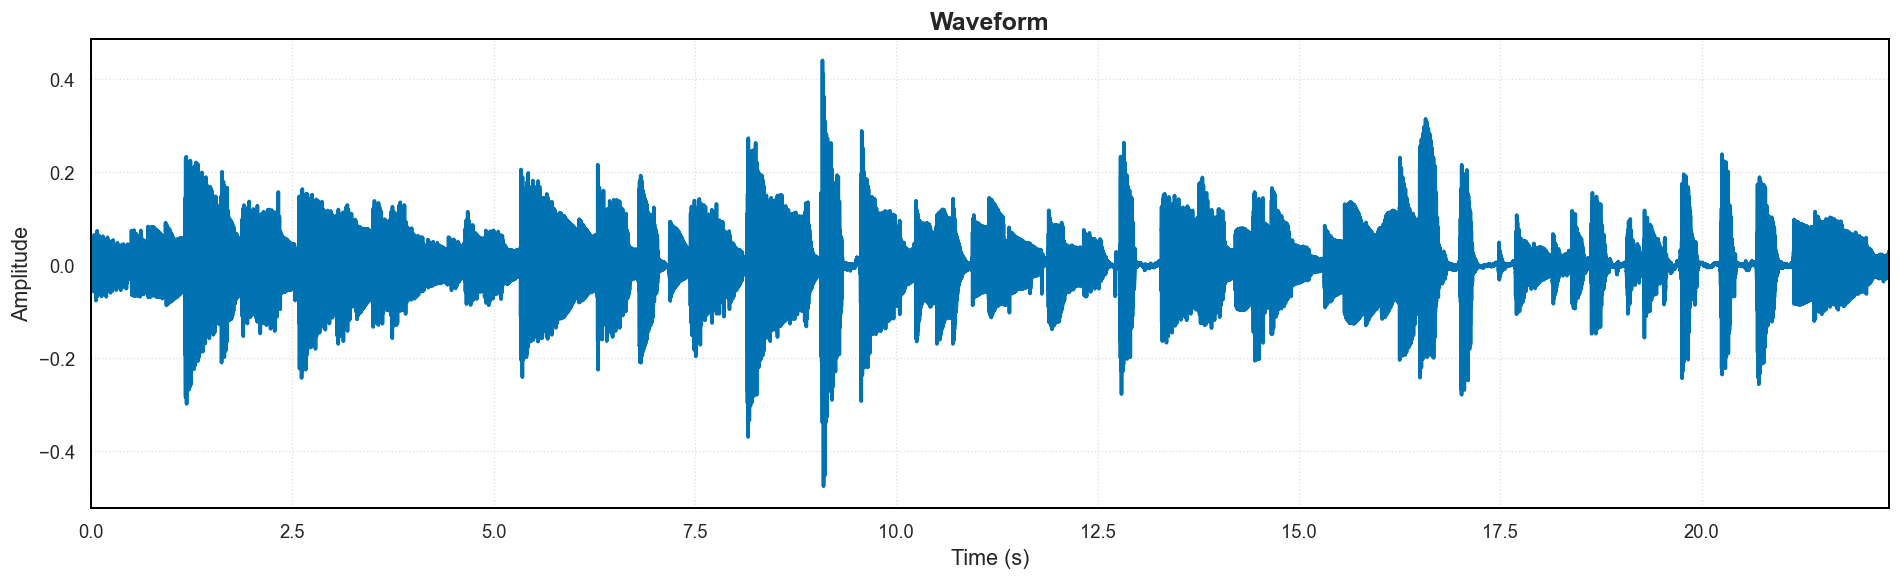

In [7]:
duration_audio = len(audio_data) / sample_rate
time_audio = np.linspace(0, duration_audio, len(audio_data))

plt.figure(figsize=(16, 5))

plt.plot(time_audio, audio_data)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [8]:
print("Durée :                    ", duration_audio)
print("Taille d'échantillonage :  ", sample_rate)
print("Amplitude moyenne :        ", np.mean(audio_data))
print("Ecart-type de l'amplitude :", np.std(audio_data))
print("Amplitude maximale :       ", np.max(audio_data))
print("Amplitude minimale :       ", np.min(audio_data))

Durée :                     22.32439909297052
Taille d'échantillonage :   44100
Amplitude moyenne :         -0.0001437703636590648
Ecart-type de l'amplitude : 0.05107147673171689
Amplitude maximale :        0.439300537109375
Amplitude minimale :        -0.475341796875


# Normalisation

In [9]:
# Import de la classe AudioNormalizer
from src.transformers.audio_normalizer import AudioNormalizer

audio_normalizer = AudioNormalizer()

## Conversion mono

La conversion d'un signal multi-canaux en mono permet de résumer l'information en un unique vecteur. L'impact est négligeable sur le modèle.

In [10]:
audio_data_mono = audio_normalizer.to_mono(audio_data=audio_data)

print(f"Nombre de canaux après conversion mono : {len(audio_data_mono.shape)}")

Nombre de canaux après conversion mono : 1


## Rééchantillonage

Le rééchantillonage permet de réduire le temps de calcul au détriment de la qualité de l'information. L'impact est modéré.

In [11]:
TARGET_SAMPLE_RATE = 22050

audio_data_resample, sample_rate_normalized = audio_normalizer.resample(
    audio_data=audio_data_mono, sample_rate=TARGET_SAMPLE_RATE
)

print("Taille d'échantillonage visé :                  ", TARGET_SAMPLE_RATE)
print("Taille d'échantillonage après rééchantillonage :", sample_rate_normalized)

Taille d'échantillonage visé :                   22050
Taille d'échantillonage après rééchantillonage : 22050


## Normalisation Peak vs RMS vs Peak+RMS

Normalisation
- peak : amplitude entre -1 et 1.
- RMS : basé sur l'énergie.
- peak + RMS : dans cet ordre.

In [12]:
audio_data_peak = audio_normalizer.normalize_audio(
    audio_data=audio_data_resample, norm_type="peak"
)

print("Amplitude moyenne :        ", np.mean(audio_data_peak))
print("Ecart-type de l'amplitude :", np.std(audio_data_peak))
print("Amplitude maximale :       ", np.max(audio_data_peak))
print("Amplitude minimale :       ", np.min(audio_data_peak))

Amplitude moyenne :         -0.00030245681024526427
Ecart-type de l'amplitude : 0.10744158638577936
Amplitude maximale :        0.9241782229070364
Amplitude minimale :        -1.0


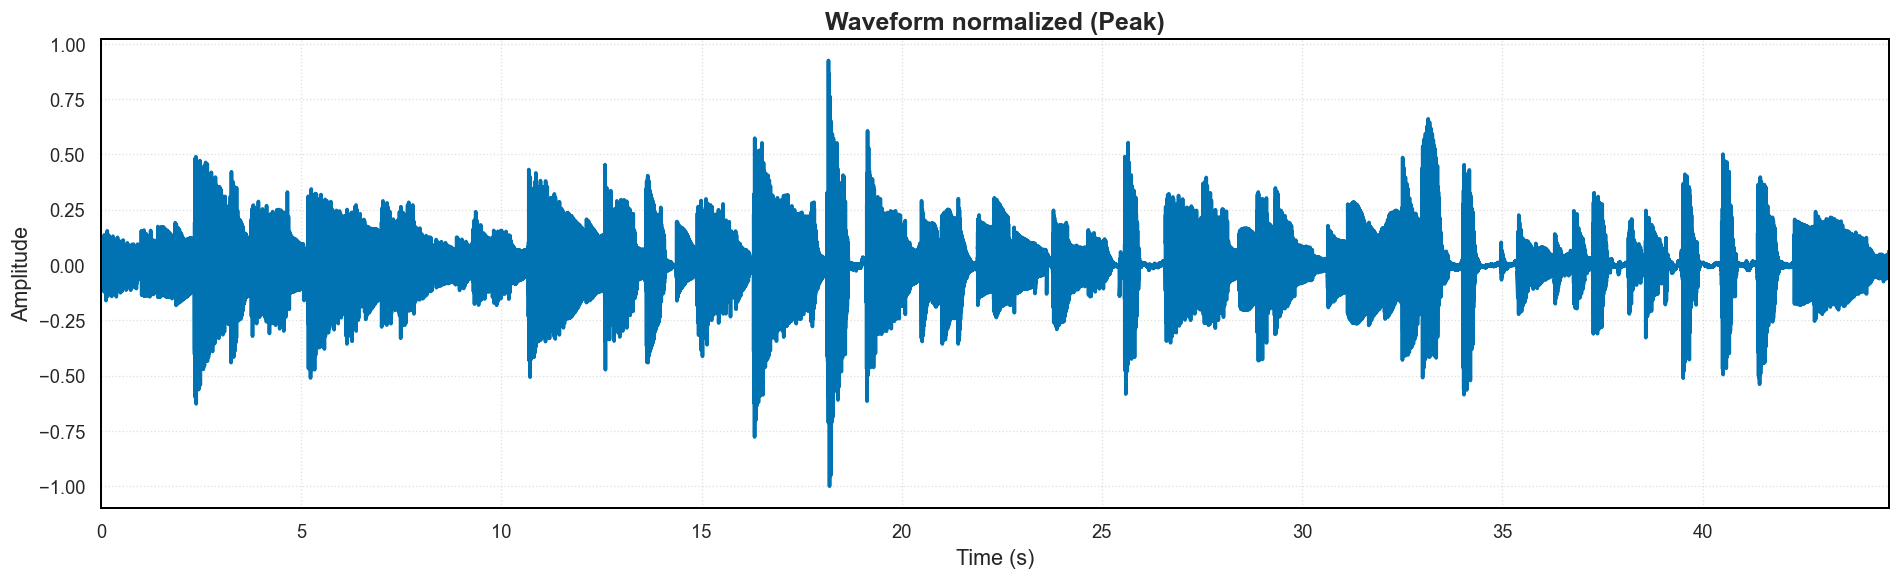

In [13]:
duration_audio_peak = len(audio_data_peak) / sample_rate_normalized
time_audio_peak = np.linspace(0, duration_audio_peak, len(audio_data_peak))

plt.figure(figsize=(16, 5))

plt.plot(time_audio_peak, audio_data_peak)
plt.title("Waveform normalized (Peak)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_peak))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [14]:
TARGET_RMS = 0.1

audio_data_rms = audio_normalizer.normalize_audio(
    audio_data=audio_data_resample, norm_type="rms", target_rms=TARGET_RMS
)

print("Amplitude moyenne :        ", np.mean(audio_data_rms))
print("Ecart-type de l'amplitude :", np.std(audio_data_rms))
print("Amplitude maximale :       ", np.max(audio_data_rms))
print("Amplitude minimale :       ", np.min(audio_data_rms))

Amplitude moyenne :         -0.00028150702348082017
Ecart-type de l'amplitude : 0.09999960376819365
Amplitude maximale :        0.8601646644536989
Amplitude minimale :        -0.930734617126142


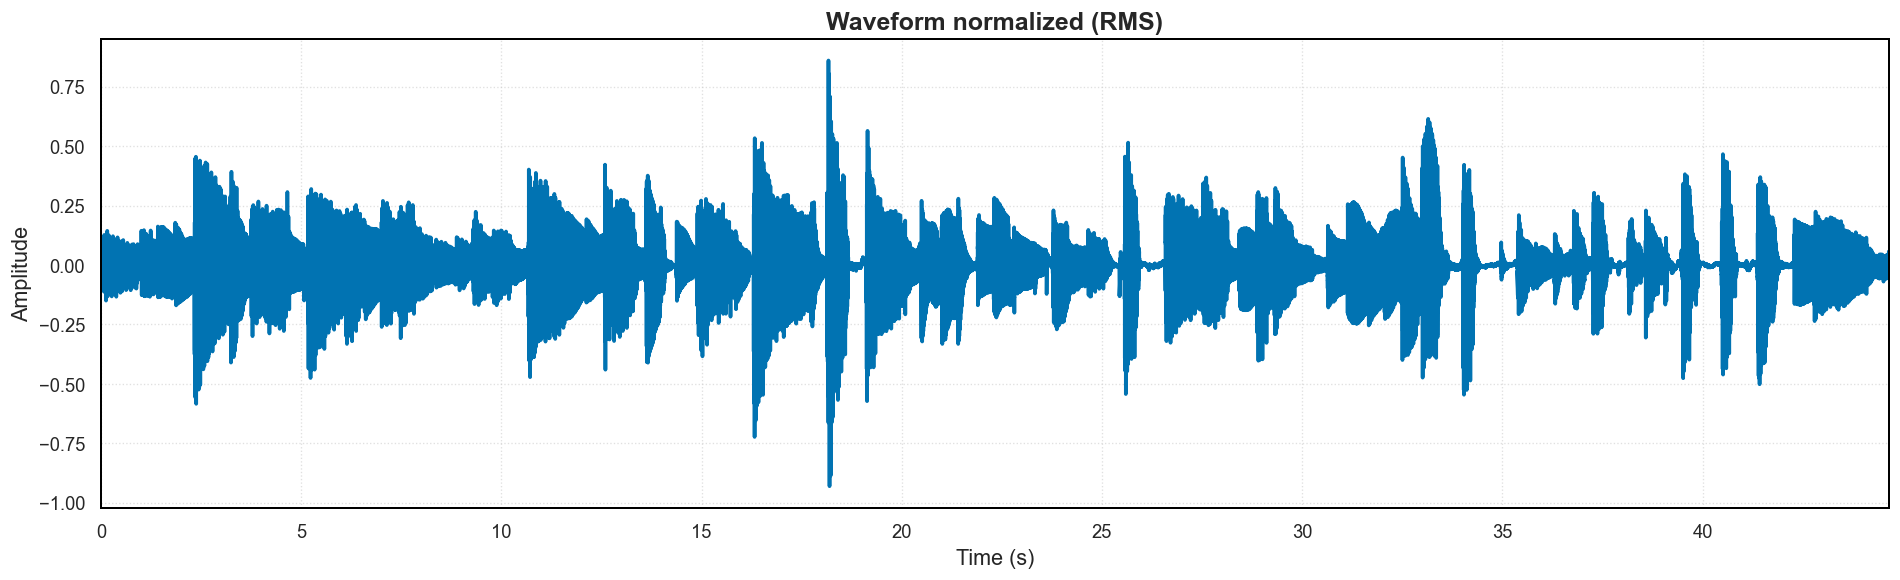

In [15]:
duration_audio_rms = len(audio_data_rms) / sample_rate_normalized
time_audio_rms = np.linspace(0, duration_audio_rms, len(audio_data_rms))

plt.figure(figsize=(16, 5))

plt.plot(time_audio_rms, audio_data_rms)
plt.title("Waveform normalized (RMS)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_rms))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [16]:
audio_data_peak_rms = audio_normalizer.normalize_audio(
    audio_data=audio_data_resample, norm_type="peak+rms", target_rms=TARGET_RMS
)

print("Amplitude moyenne :        ", np.mean(audio_data_peak_rms))
print("Ecart-type de l'amplitude :", np.std(audio_data_peak_rms))
print("Amplitude maximale :       ", np.max(audio_data_peak_rms))
print("Amplitude minimale :       ", np.min(audio_data_peak_rms))

Amplitude moyenne :         -0.00028150702348082017
Ecart-type de l'amplitude : 0.09999960376819367
Amplitude maximale :        0.8601646644536989
Amplitude minimale :        -0.930734617126142


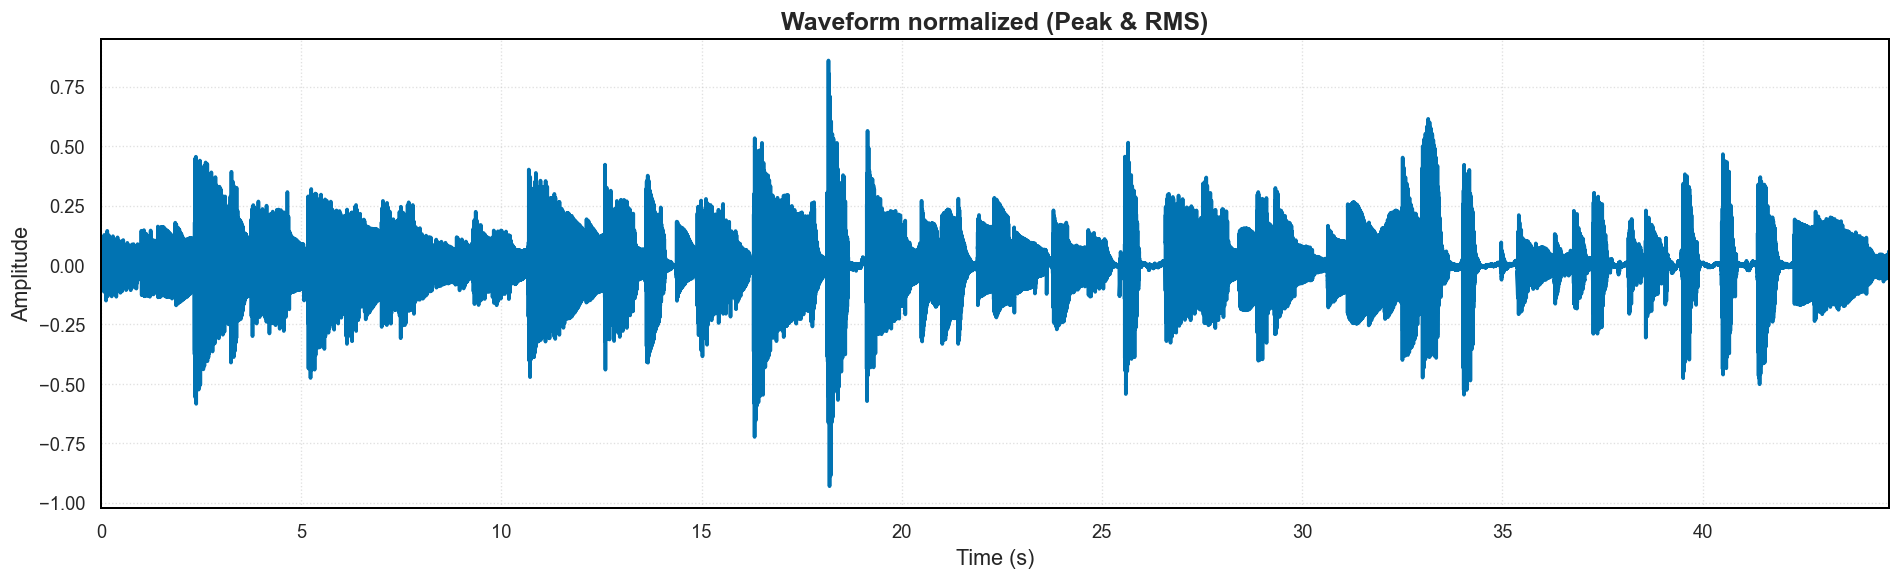

In [17]:
duration_audio_peak_rms = len(audio_data_peak_rms) / sample_rate_normalized
time_audio_peak_rms = np.linspace(0, duration_audio_peak_rms, len(audio_data_peak_rms))

plt.figure(figsize=(16, 5))

plt.plot(time_audio_peak_rms, audio_data_peak_rms)
plt.title("Waveform normalized (Peak & RMS)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_peak_rms))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [18]:
audio_data_normalized = audio_data_peak_rms

# Nettoyage

In [19]:
# Import de la classe AudioCleaner
from src.transformers.audio_cleaner import AudioCleaner

audio_cleaner = AudioCleaner()

## High-pass filter

Filtre les basses fréquences.

In [20]:
CUTOFF_HIGHT = 80  # Hz

audio_data_highpass_filtered = audio_cleaner.highpass_filter(
    audio_data=audio_data_normalized,
    sample_rate=sample_rate_normalized,
    cutoff=CUTOFF_HIGHT,
)

print("Amplitude moyenne :        ", np.mean(audio_data_highpass_filtered))
print("Ecart-type de l'amplitude :", np.std(audio_data_highpass_filtered))
print("Amplitude maximale :       ", np.max(audio_data_highpass_filtered))
print("Amplitude minimale :       ", np.min(audio_data_highpass_filtered))

Amplitude moyenne :         -8.512444649169831e-07
Ecart-type de l'amplitude : 0.09192856141398209
Amplitude maximale :        0.9347490515524287
Amplitude minimale :        -0.6664115402427332


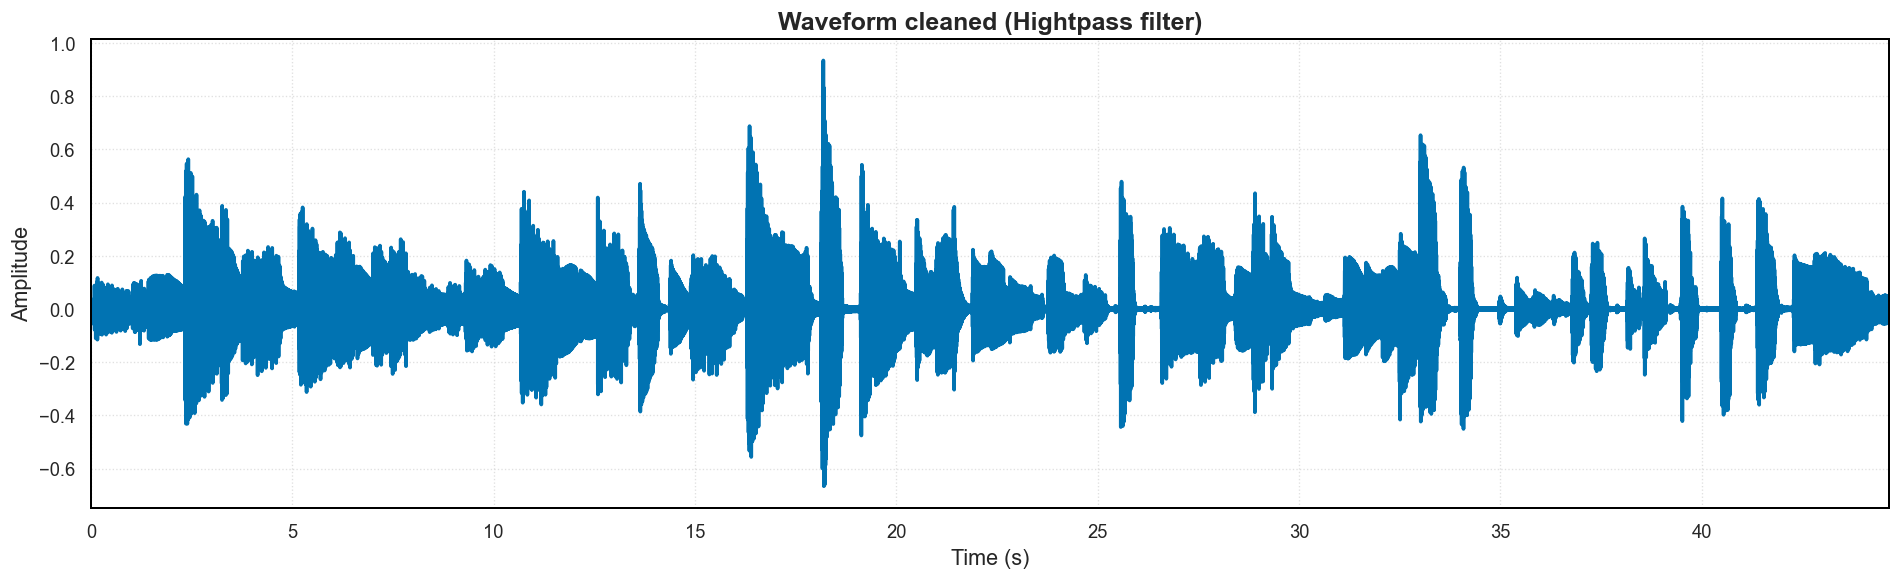

In [21]:
duration_audio_highpass_filtered = (
    len(audio_data_highpass_filtered) / sample_rate_normalized
)
time_audio_highpass_filtered = np.linspace(
    0, duration_audio_highpass_filtered, len(audio_data_highpass_filtered)
)

plt.figure(figsize=(16, 5))

plt.plot(time_audio_highpass_filtered, audio_data_highpass_filtered)
plt.title("Waveform cleaned (Hightpass filter)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_highpass_filtered))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

## Low-pass filter

Filtre les hautes fréquences.

In [22]:
CUTOFF_LOW = 8_000  # Hz

audio_data_lowpass_filtered = audio_cleaner.lowpass_filter(
    audio_data=audio_data_normalized,
    sample_rate=sample_rate_normalized,
    cutoff=CUTOFF_LOW,
)

print("Amplitude moyenne :        ", np.mean(audio_data_lowpass_filtered))
print("Ecart-type de l'amplitude :", np.std(audio_data_lowpass_filtered))
print("Amplitude maximale :       ", np.max(audio_data_lowpass_filtered))
print("Amplitude minimale :       ", np.min(audio_data_lowpass_filtered))

Amplitude moyenne :         -0.0002815917507225673
Ecart-type de l'amplitude : 0.0999990857777811
Amplitude maximale :        0.8594732420284744
Amplitude minimale :        -0.9312509304739641


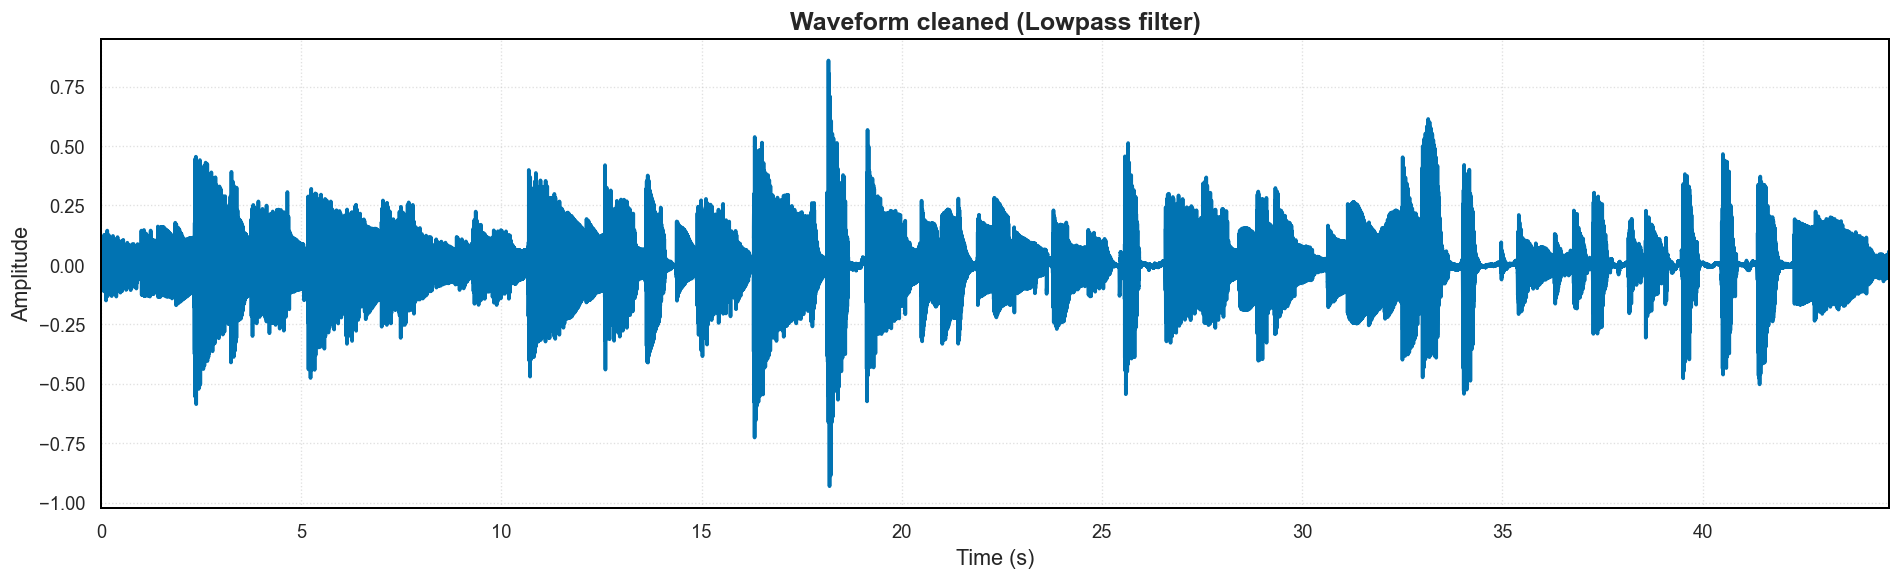

In [23]:
duration_audio_lowpass_filtered = (
    len(audio_data_lowpass_filtered) / sample_rate_normalized
)
time_audio_lowpass_filtered = np.linspace(
    0, duration_audio_lowpass_filtered, len(audio_data_lowpass_filtered)
)

plt.figure(figsize=(16, 5))

plt.plot(time_audio_lowpass_filtered, audio_data_lowpass_filtered)
plt.title("Waveform cleaned (Lowpass filter)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_lowpass_filtered))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

## Wiener filtering

Supprime le bruit.

In [24]:
NOISE_REDUCTION_FACTOR = 10

audio_data_wiener_filtered = audio_cleaner.wiener_filter(
    audio_data=audio_data_normalized, noise_reduction_factor=NOISE_REDUCTION_FACTOR
)

print("Amplitude moyenne :        ", np.mean(audio_data_wiener_filtered))
print("Ecart-type de l'amplitude :", np.std(audio_data_wiener_filtered))
print("Amplitude maximale :       ", np.max(audio_data_wiener_filtered))
print("Amplitude minimale :       ", np.min(audio_data_wiener_filtered))

Amplitude moyenne :         -0.0001399684726649777
Ecart-type de l'amplitude : 0.08482764905378817
Amplitude maximale :        0.8109165465192462
Amplitude minimale :        -0.9243862683432853


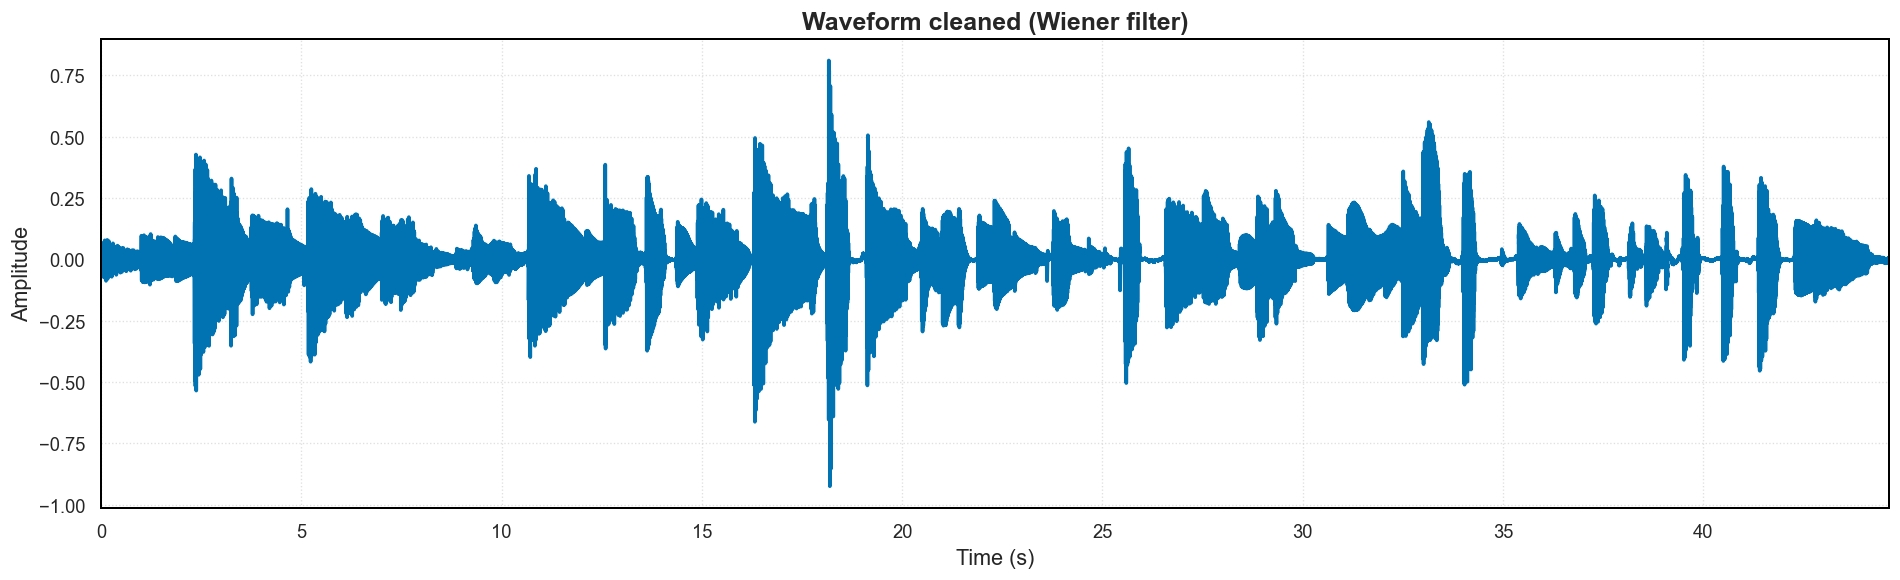

In [25]:
duration_audio_wiener_filtered = (
    len(audio_data_wiener_filtered) / sample_rate_normalized
)
time_audio_wiener_filtered = np.linspace(
    0, duration_audio_wiener_filtered, len(audio_data_wiener_filtered)
)

plt.figure(figsize=(16, 5))

plt.plot(time_audio_wiener_filtered, audio_data_wiener_filtered)
plt.title("Waveform cleaned (Wiener filter)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_wiener_filtered))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

## Spectral denoise

Supprime le bruit avec une méthode spectrale.

In [26]:
audio_data_spectral_denoise = audio_cleaner.spectral_denoise(
    audio_data=audio_data_normalized
)

print("Amplitude moyenne :        ", np.mean(audio_data_spectral_denoise))
print("Ecart-type de l'amplitude :", np.std(audio_data_spectral_denoise))
print("Amplitude maximale :       ", np.max(audio_data_spectral_denoise))
print("Amplitude minimale :       ", np.min(audio_data_spectral_denoise))

Amplitude moyenne :         -0.00020029677394913068
Ecart-type de l'amplitude : 0.09956748620791771
Amplitude maximale :        0.8560033031629732
Amplitude minimale :        -0.9305778206951225


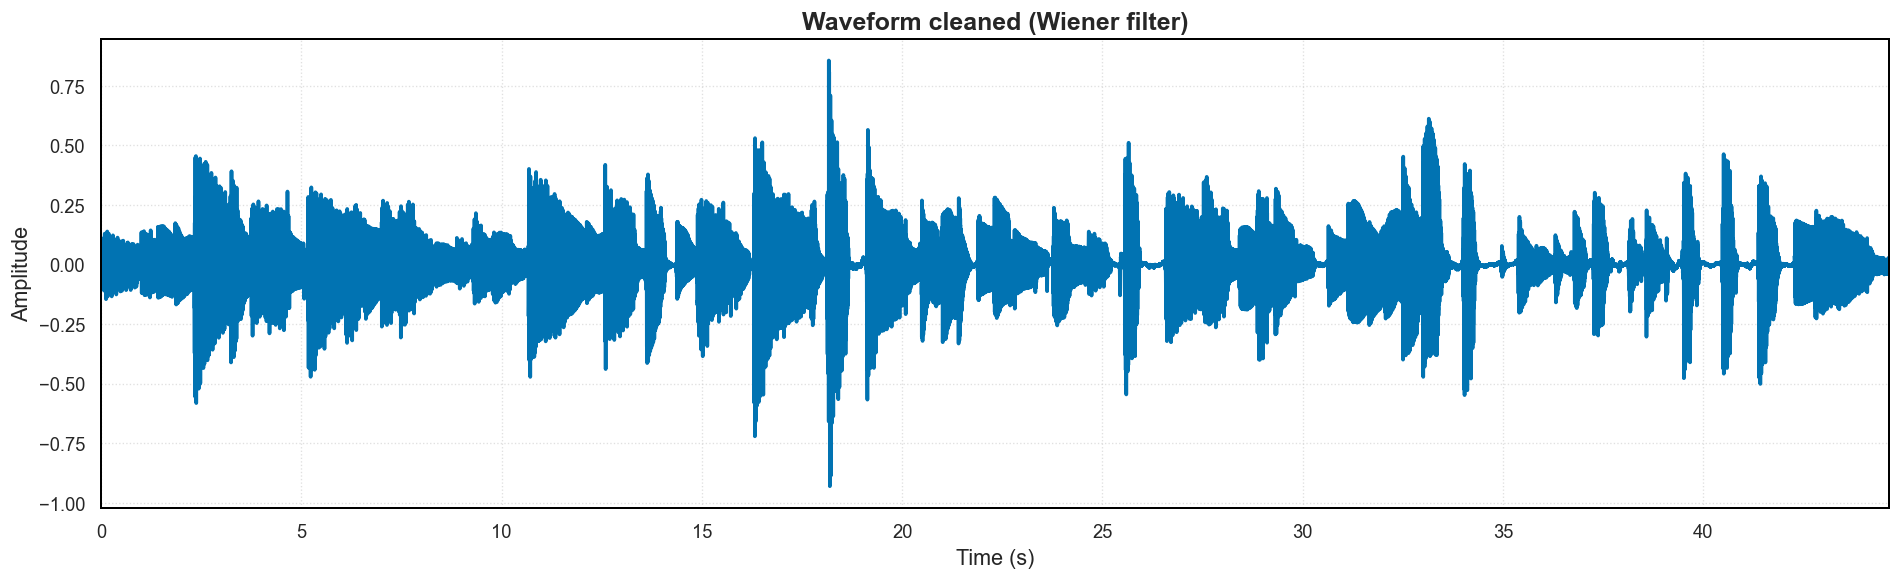

In [27]:
duration_audio_spectral_denoise = (
    len(audio_data_spectral_denoise) / sample_rate_normalized
)
time_audio_spectral_denoise = np.linspace(
    0, duration_audio_spectral_denoise, len(audio_data_spectral_denoise)
)

plt.figure(figsize=(16, 5))

plt.plot(time_audio_spectral_denoise, audio_data_spectral_denoise)
plt.title("Waveform cleaned (Wiener filter)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_spectral_denoise))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

## Silence trimming

Supprime les silences au début et à la fin de l'audio. Non utilisé pour sur les datasets GuitarSet et IDMT-SMT-Guitar pour ne pas décaller l'alignement avec les annotations.

In [28]:
TOP_DB = 60

audio_data_trimmed = audio_cleaner.trim_silence(audio_data=audio_data, top_db=TOP_DB)

duration_audio_normalized = len(audio_data_normalized) / sample_rate_normalized
duration_audio_trimmed = len(audio_data_trimmed) / sample_rate_normalized

print("Durée audio normalisé :", duration_audio_normalized)
print("Durée audio nettoyé   :", duration_audio_trimmed)

Durée audio normalisé : 44.64879818594104
Durée audio nettoyé   : 44.64879818594104
